# 📱 Predict Mobile Phone Pricing Using Machine Learning

## 📌 Objective
Build a machine learning system that predicts the **price range of mobile phones**
(low, medium, high, very high) based on their specifications.

## 🧠 Problem Type
- Supervised Learning
- Multiclass Classification

## 🎯 Target Variable
**price_range**
- 0 → Low Cost
- 1 → Medium Cost
- 2 → High Cost
- 3 → Very High Cost


## 📊 Dataset Description

The dataset contains specifications of mobile phones available in the market.

### Features:
- battery_power: Battery capacity (mAh)
- blue: Bluetooth support (0/1)
- clock_speed: Processor speed
- dual_sim: Dual SIM support
- fc: Front camera (MP)
- four_g: 4G support
- int_memory: Internal memory (GB)
- m_deep: Mobile depth (cm)
- mobile_wt: Weight (gm)
- n_cores: Number of CPU cores
- pc: Primary camera (MP)
- px_height: Pixel resolution height
- px_width: Pixel resolution width
- ram: RAM (MB)
- sc_h: Screen height (cm)
- sc_w: Screen width (cm)
- talk_time: Battery talk time (hours)
- three_g: 3G support
- touch_screen: Touch screen support
- wifi: WiFi support


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [6]:
df = pd.read_csv("dataset.csv")
df.head()


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [8]:
df.isnull().sum()


battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [9]:
df.describe()


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


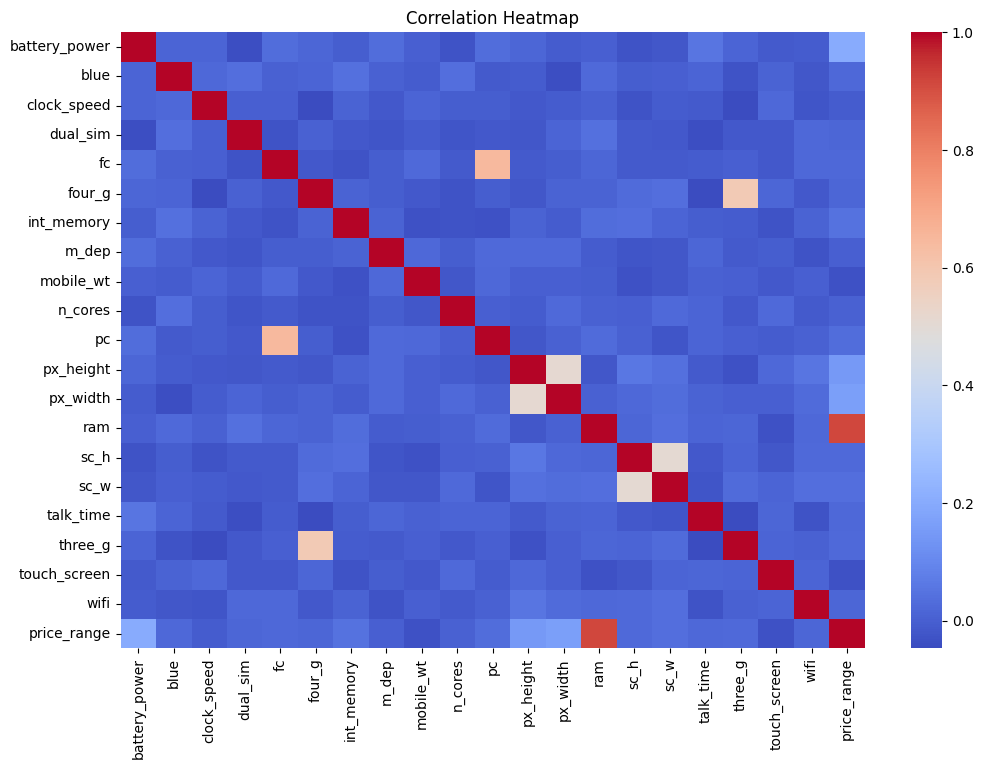

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [11]:
X = df.drop("price_range", axis=1)
y = df["price_range"]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [14]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.975


In [15]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))


KNN Accuracy: 0.53


In [16]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 0.835


In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.8925


In [18]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Accuracy: 0.8925


In [19]:
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.95      0.96      0.96       105
           1       0.89      0.87      0.88        91
           2       0.78      0.87      0.82        92
           3       0.94      0.87      0.90       112

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.90      0.89      0.89       400



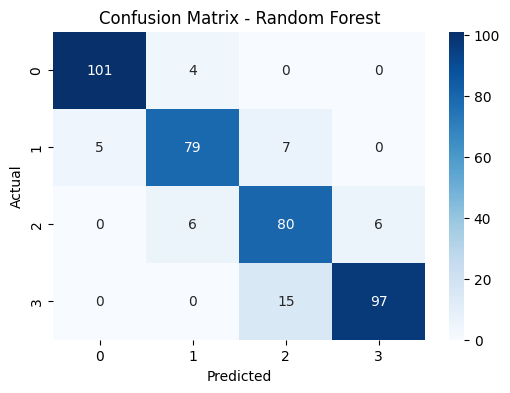

In [20]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()


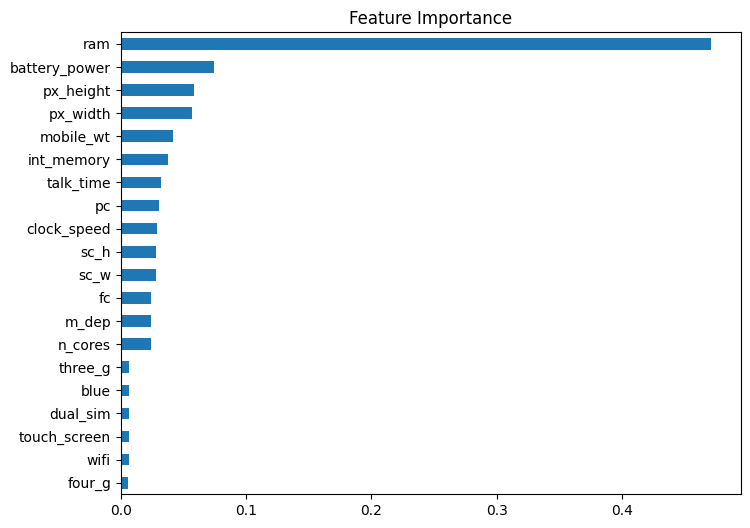

In [21]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=df.drop("price_range", axis=1).columns
)

feature_importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()


In [22]:
# Predict first 5 test samples
predictions = rf.predict(X_test[:5])
actual = y_test.iloc[:5]

result = pd.DataFrame({
    "Actual Price Range": actual.values,
    "Predicted Price Range": predictions
})

result


,Actual Price Range,Predicted Price Range
0,0,0
1,2,2
2,1,1
3,3,3
4,1,1


In [23]:
# Example: New mobile phone specifications
new_mobile = {
    "battery_power": 3000,
    "blue": 1,
    "clock_speed": 2.0,
    "dual_sim": 1,
    "fc": 8,
    "four_g": 1,
    "int_memory": 64,
    "m_dep": 0.8,
    "mobile_wt": 170,
    "n_cores": 8,
    "pc": 48,
    "px_height": 1920,
    "px_width": 1080,
    "ram": 4096,
    "sc_h": 15,
    "sc_w": 7,
    "talk_time": 20,
    "three_g": 1,
    "touch_screen": 1,
    "wifi": 1
}

# Convert to DataFrame
new_mobile_df = pd.DataFrame([new_mobile])

# Scale features 
new_mobile_scaled = scaler.transform(new_mobile_df)

# Predict price range
prediction = rf.predict(new_mobile_scaled)[0]

# Map prediction to label
price_map = {
    0: "Low Cost",
    1: "Medium Cost",
    2: "High Cost",
    3: "Very High Cost"
}

print("Predicted Price Range:", price_map[prediction])


Predicted Price Range: Very High Cost


In [24]:
proba = rf.predict_proba(new_mobile_scaled)

proba_df = pd.DataFrame(
    proba,
    columns=["Low", "Medium", "High", "Very High"]
)

proba_df


,Low,Medium,High,Very High
0,0.01,0.08,0.18,0.73


In [25]:
import pickle

pickle.dump(rf, open('model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

## ✅ Conclusion

In this project, we successfully built a **Mobile Phone Pricing Prediction System**
using machine learning classification algorithms.

### Key Observations:
- Random Forest achieved the highest accuracy
- RAM, battery power, and screen resolution were the most influential features
- Feature scaling improved the performance of KNN and SVM

### Final Outcome:
The model can accurately classify mobile phones into
Low, Medium, High, and Very High price ranges.

### Future Scope:
- Hyperparameter tuning using GridSearchCV
- Deploying the model using Flask or Streamlit
- Using real-time mobile specifications as input
